Lectura del archivo y normalizacion del archivo y lecutra de los modulos de la automatizacion


In [9]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import sys
import os
import pandas as pd
from pathlib import Path



# 1. Detectar raíz del proyecto (subiendo desde el cwd)
project_root = Path(os.getcwd()).resolve().parent  # sube un nivel desde notebooks/
sys.path.append(str(project_root))

# 2. Ruta hacia el módulo src/
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# 3. Importar módulos desde src/
from src.data_loading import (
    cargar_datos_excel
)
from src.data_cleaning import (
    estandarizar_columnas,
    convertir_fechas,
)
from src.logistica import (
    calcular_tiempo_entrega,    
)
from src.exportacion import (
    exportar_excel,
)




In [11]:
ruta_excel = "../data/raw/Sales report completa.xlsx" 
df = cargar_datos_excel(ruta_excel, sheet_name="Ventas Supermercado")
df = estandarizar_columnas(df)
df = convertir_fechas(df)
df = calcular_tiempo_entrega(df)

In [14]:
pd.DataFrame(df.columns, columns=['Columnas'])


,Columnas
0,numero_venta
1,mes_salida
2,dia_salida
3,ano_salida
4,mes_entrega
5,dia_entrega
6,ano_entrega
7,metodo_envio
8,numero_cliente
9,nombre_cliente


In [18]:
df['tiempo_entrega'].describe()


count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: tiempo_entrega, dtype: float64

/tmp/ipykernel_1067/3444460739.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='metodo_envio', y='tiempo_entrega', palette='Set2')


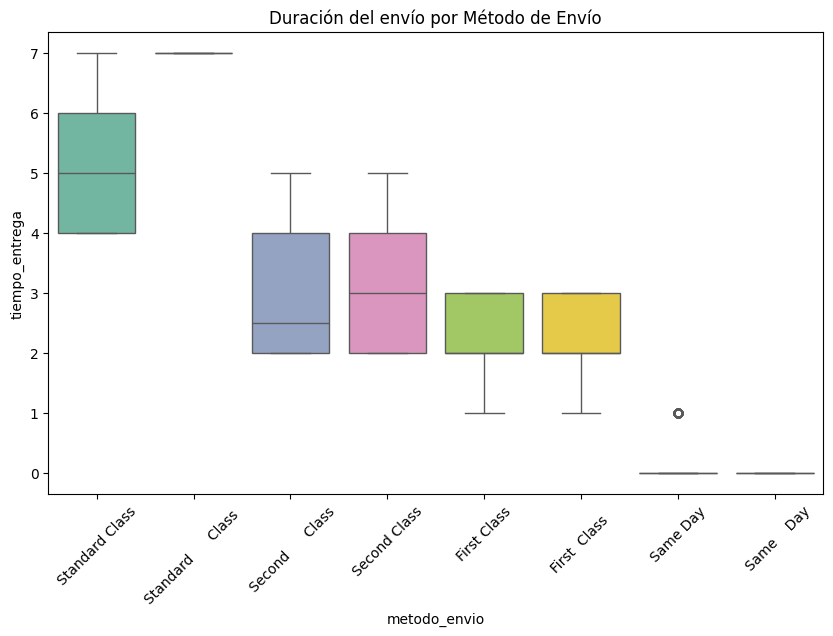

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='metodo_envio', y='tiempo_entrega', palette='Set2')
plt.title('Duración del envío por Método de Envío')
plt.xticks(rotation=45)
plt.show()


In [21]:
df['metodo_envio'] = df['metodo_envio'].str.strip().str.replace(r'\s+', ' ', regex=True)


In [24]:
df['metodo_envio'].unique()


array(['Standard Class', 'Second Class', 'First Class', 'Same Day'],
      dtype=object)

/tmp/ipykernel_1067/2045890763.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='metodo_envio', y='tiempo_entrega', palette='Set2')


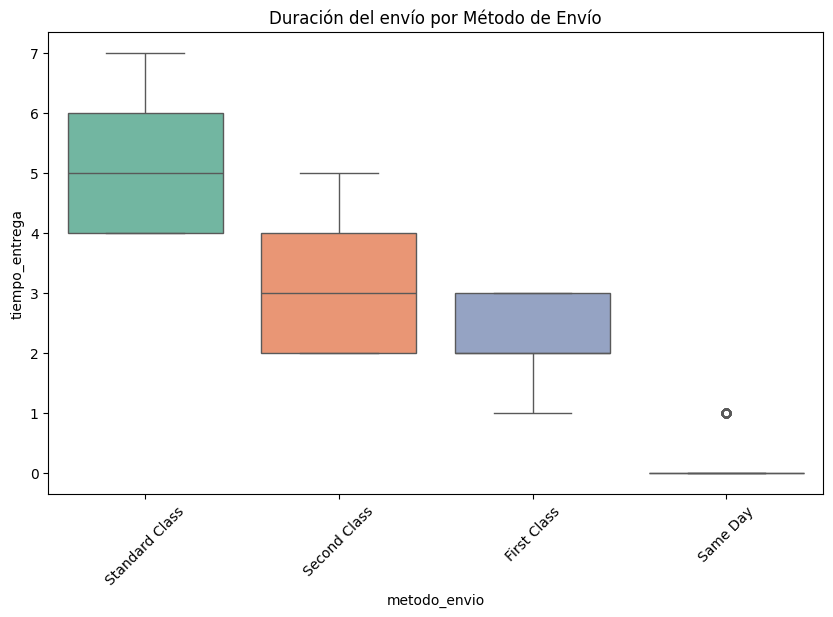

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='metodo_envio', y='tiempo_entrega', palette='Set2')
plt.title('Duración del envío por Método de Envío')
plt.xticks(rotation=45)
plt.show()

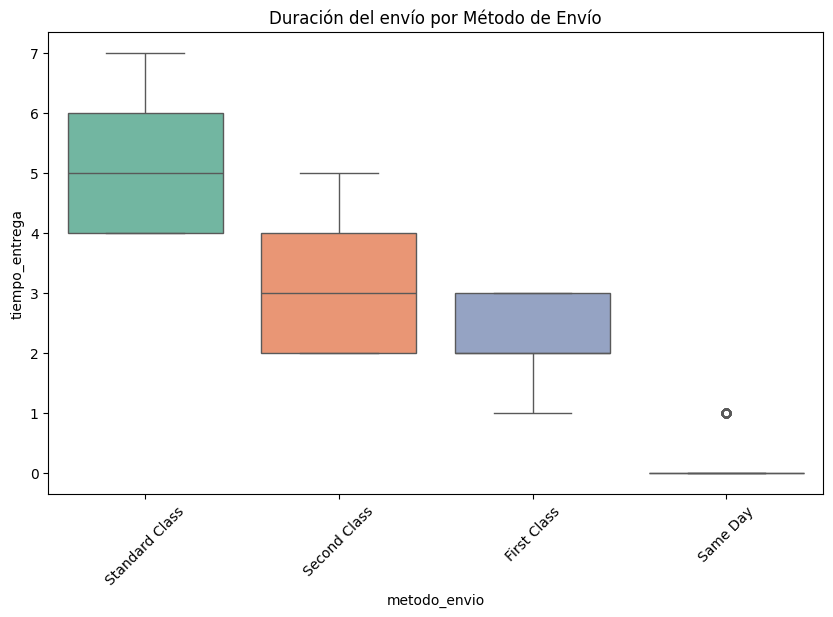

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='metodo_envio',
    y='tiempo_entrega',
    hue='metodo_envio',
    palette='Set2',
    legend=False
)
plt.title('Duración del envío por Método de Envío')
plt.xticks(rotation=45)
plt.show()


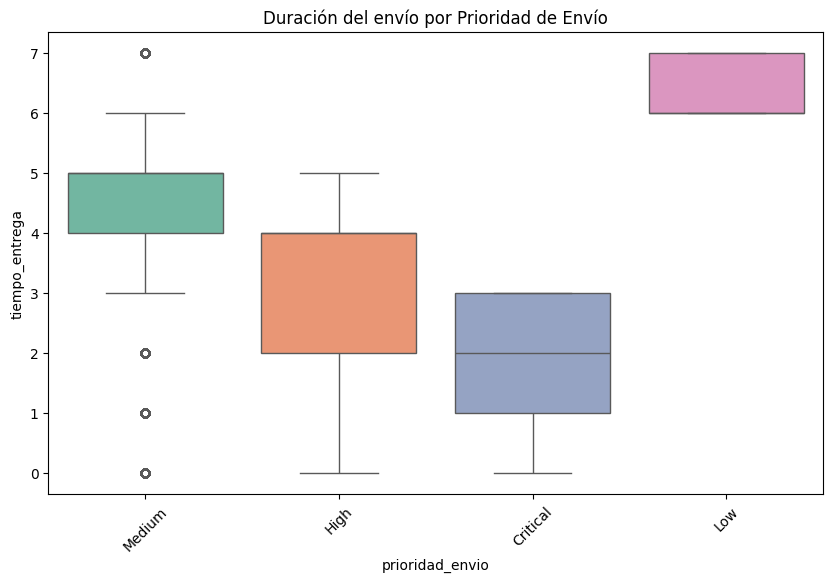

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='prioridad_envio',
    y='tiempo_entrega',
    hue='prioridad_envio',
    palette='Set2',
    legend=False
)
plt.title('Duración del envío por Prioridad de Envío')
plt.xticks(rotation=45)
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='pais',
    y='tiempo_entrega',
    hue='pais',
    palette='Set2',
    legend=False
)
plt.title('Duración del envío por Pais')
plt.xticks(rotation=45)
plt.show()

NameError: name 'plt' is not defined